02 - Analise de pedidos 

Objetivo: Entender o ciclo de vida dos pedidas na plataforma Olist.

Perguntas que esse notebook responde: 
- Qual o volume de pedidos ao longo do tempo? Existe sazonalidade? 
- Qual o tempo médio de entrega por estado?
- Pedidos atrasados recebem avaliações piores? 
- Quais os métodos de pagamento mais usados?

Datasets utilizados: orders, order_item, payments e revies.

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

In [4]:
DATA_PATH = '../data/raw/' 

orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')

In [5]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in date_cols: 
    orders[col] = pd.to_datetime(orders[col])

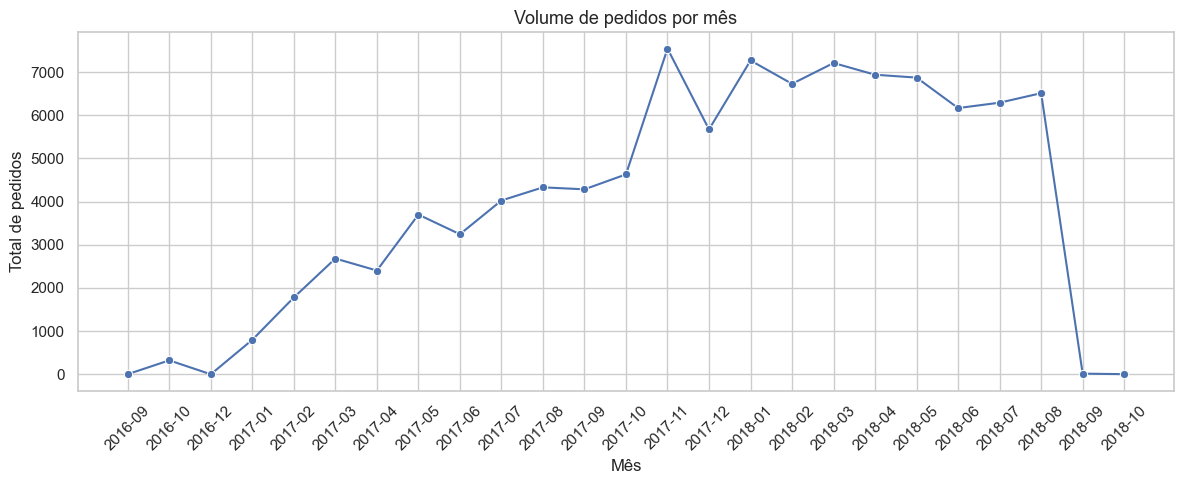

In [9]:
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_volume = (
    orders
    .groupby('year_month')
    .size()
    .reset_index(name='orders_total')
)

monthly_volume['year_month'] = monthly_volume['year_month'].astype(str)

fig, ax = plt.subplots()
sns.lineplot(data=monthly_volume, x='year_month', y='orders_total', ax=ax, marker='o')

ax.set_title('Volume de pedidos por mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Total de pedidos')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/02_montly_volume.png', dpi=150, bbox_inches='tight')
plt.show()